In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
import seaborn as sns


In [ ]:

np.random.seed(42)
X1 = np.random.rand(100, 1) * 10  # Variable independiente 1
X2 = np.random.rand(100, 1) * 5   # Variable independiente 2

y = 3*X1 + 2*X2 + np.random.randn(100, 1) * 2

df = pd.DataFrame({
    'X1': X1.flatten(),
    'X2': X2.flatten(),
    'y': y.flatten()
})
df.head()


,X1,X2,y
0,3.745401,0.157146,10.190446
1,9.507143,3.182052,35.350041
2,7.319939,1.571780,25.689523
3,5.986585,2.542853,21.616759
4,1.560186,4.537832,17.487773


Descripción estadística:
               X1          X2           y
count  100.000000  100.000000  100.000000
mean     4.701807    2.489159   19.299806
std      2.974894    1.465556    9.441079
min      0.055221    0.034761    2.703276
25%      1.932008    1.210023   12.498446
50%      4.641425    2.528124   18.451273
75%      7.302031    3.830918   27.443021
max      9.868869    4.928252   40.336300


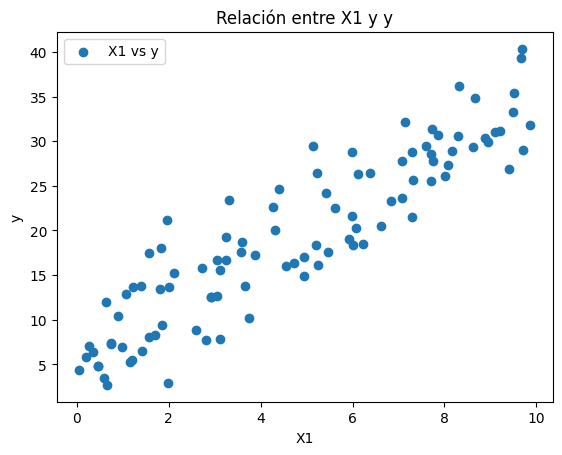

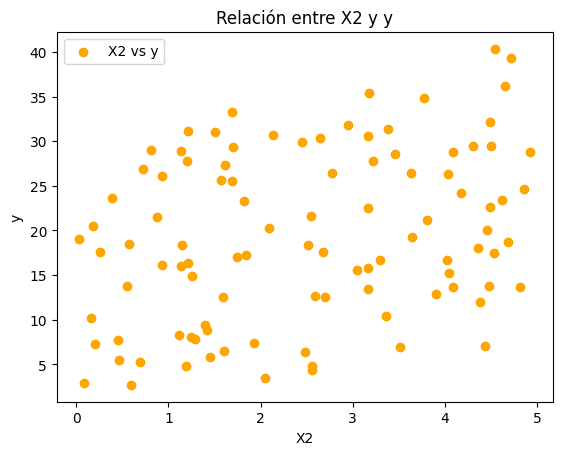

In [ ]:

print("Descripción estadística:")
print(df.describe())

plt.scatter(df['X1'], df['y'], label="X1 vs y")
plt.xlabel("X1")
plt.ylabel("y")
plt.title("Relación entre X1 y y")
plt.legend()
plt.show()

plt.scatter(df['X2'], df['y'], label="X2 vs y", color='orange')
plt.xlabel("X2")
plt.ylabel("y")
plt.title("Relación entre X2 y y")
plt.legend()
plt.show()


In [ ]:

X_simple = df[['X1']]
X_multiple = df[['X1', 'X2']]
y = df['y']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multiple, y, test_size=0.2, random_state=42)


In [ ]:

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

model_multiple = LinearRegression()
model_multiple.fit(X_train_m, y_train_m)



LinearRegression()

In [ ]:
print("Modelo de regresión lineal simple")
print("Intercepto:", model_simple.intercept_)
print("Coeficiente:", model_simple.coef_)

print("Modelo de regresión lineal múltiple")
print("Intercepto:", model_multiple.intercept_)
print("Coeficientes:", model_multiple.coef_)

#print (model_multiple.intercept_ , model_simple. coef_)

Modelo de regresión lineal simple
Intercepto: 5.7434256048633205
Coeficiente: [2.88216985]
Modelo de regresión lineal múltiple
Intercepto: -0.4134850220529671
Coeficientes: [2.95000442 2.3148695 ]


In [ ]:

y_pred_simple = model_simple.predict(X_test_s)
y_pred_multiple = model_multiple.predict(X_test_m)


In [ ]:

def evaluar_modelo(y_true, y_pred, nombre):
    print(f"\nEvaluación del modelo {nombre}:")
    print("MAE (Error absoluto medio):", mean_absolute_error(y_true, y_pred))
    print("MSE (Error cuadrático medio):", mean_squared_error(y_true, y_pred))
    print("R² (Coeficiente de determinación):", r2_score(y_true, y_pred))
    print("Puntuación de varianza explicada:", explained_variance_score(y_true, y_pred))



evaluar_modelo(y_test_s, y_pred_simple, "Regresión Lineal Simple")
evaluar_modelo(y_test_m, y_pred_multiple, "Regresión Lineal Múltiple")



Evaluación del modelo Regresión Lineal Simple:
MAE (Error absoluto medio): 3.0088368121635356
MSE (Error cuadrático medio): 14.010332622572875
R² (Coeficiente de determinación): 0.8582151194116621
Puntuación de varianza explicada: 0.8582213766576446

Evaluación del modelo Regresión Lineal Múltiple:
MAE (Error absoluto medio): 1.4666296491800523
MSE (Error cuadrático medio): 2.6657283954607585
R² (Coeficiente de determinación): 0.9730227688083299
Puntuación de varianza explicada: 0.9746770265161786


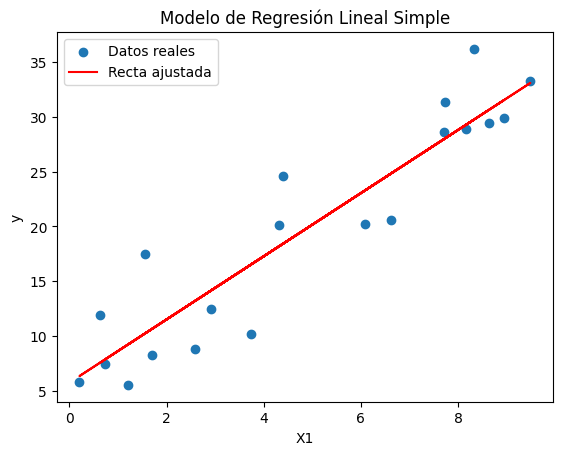

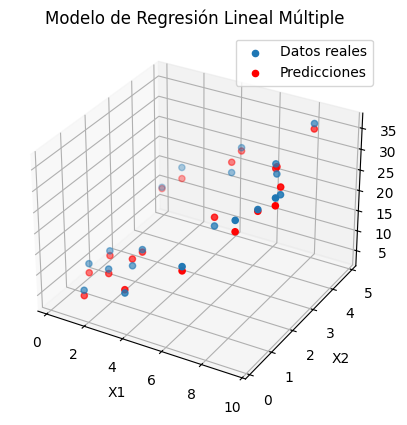

In [ ]:

plt.scatter(X_test_s, y_test_s, label="Datos reales")
plt.plot(X_test_s, y_pred_simple, color='red', label="Recta ajustada")
plt.xlabel("X1")
plt.ylabel("y")
plt.title("Modelo de Regresión Lineal Simple")
plt.legend()
plt.show()

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test_m['X1'], X_test_m['X2'], y_test_m, label="Datos reales")
ax.scatter(X_test_m['X1'], X_test_m['X2'], y_pred_multiple, color='red', label="Predicciones")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("y")
plt.title("Modelo de Regresión Lineal Múltiple")
plt.legend()
plt.show()
